In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def flux(u):
    return 0.5 * u**2

def flux_godunov(ul, ur):
    if ul > ur:#choc
        s= 0.5*(ur+ul)   #vitesse de la discontinuité

        return flux(ul) if s>0 else flux(ur) # si s>0 le choc se déplace vers la droite, sinon vers la gauche
    else: #détente
        if ul>=0:
            return flux(ul) #tout vers la droite
        elif ur<=0:
            return flux(ur) #tout vers la droite
        else:
            return 0.

def muscl_reconstruction(u, beta, phi):
    N = len(u)
    ul = np.zeros(N)
    ur = np.zeros(N)
    for i in range(1, N-2):
        delta_p = u[i+1] - u[i]
        delta_m = u[i] - u[i-1]
        delta_pp = u[i+2] - u[i+1]

        phi_l = phi(delta_m/delta_p)
        phi_r = phi(delta_pp/delta_p)

        ul[i] = u[i] + phi_l*0.25*((1-beta)*delta_p +(1+beta)*delta_m)
        ur[i] = u[i+1] - phi_r*0.25*((1-beta)*delta_pp + (1+beta)*delta_p)

    #cdt aux bords
    ul[N-2] = u[N-2]
    ur[N-2] = u[N-1]
    ul[N-1] = u[N-1]
    ur[N-1] = u[N-1]

    # bords extrêmes
    ul[0] = u[0]
    ur[0] = u[1]
    ul[-1] = u[-1]
    ur[-1] = u[-1]

    return ul, ur

In [ ]:
def solve(x, u0, T, dt_init, beta, phi):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.9*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK
        ul, ur = muscl_reconstruction(u, beta, phi)
        u_star = np.zeros_like(u)

        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1])

        #cdt aux bords (Neumann)
        u_star[0] = u_star[1]
        u_star[-1] = u_star[-2]

        ######Étape 2 de RK
        ul_star, ur_star = muscl_reconstruction(u_star, beta, phi)
        phi_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u[1:-1] = u[1:-1] - (dt/dx)*(phi_star[1:] - phi_star[:-1])

        #cdt aux bords (Neumann)
        u[0] = u[1]
        u[-1] = u[-2]

        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

In [ ]:
def u_init(x):
    return np.where(x>0, 0., 1.)

def u_exact0(x, t):
    return np.where(x/t < 0.5, 1., 0.)

def phi1(r):#Limiteur de Van Albada
    return np.where(r>0, (r**2+r)/(r**2+1), 0)


/tmp/ipython-input-2-3389133922.py:29: RuntimeWarning: invalid value encountered in scalar divide
  phi_l = phi(delta_m/delta_p)
/tmp/ipython-input-2-3389133922.py:30: RuntimeWarning: invalid value encountered in scalar divide
  phi_r = phi(delta_pp/delta_p)
/tmp/ipython-input-2-3389133922.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  phi_r = phi(delta_pp/delta_p)
/tmp/ipython-input-10-638924254.py:8: RuntimeWarning: invalid value encountered in scalar add
  return np.where(r>0, (r**2+r)/(r**2+1), 0)
/tmp/ipython-input-2-3389133922.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  phi_l = phi(delta_m/delta_p)


Nb. iter = 500


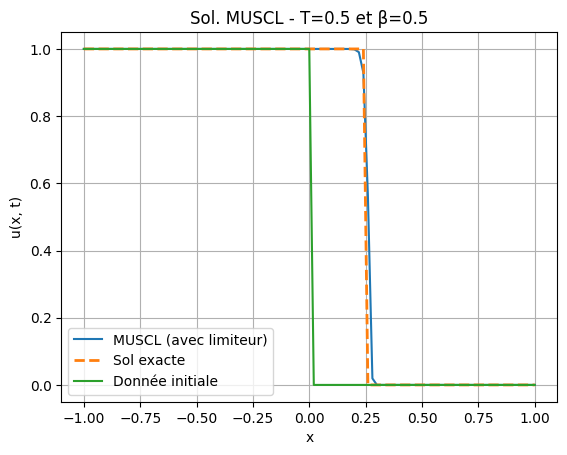

In [ ]:
N = 100
X = np.linspace(-1, 1, N+1)

U0 = u_init(X)
T = 0.5
dt_init = 1e-3
beta = 1./2  #beta = 1 schéma centré

U_ex = u_exact0(X, T)

U_muscl = solve(X, U0, T, dt_init, beta, phi1)
plt.plot(X, U_muscl, '-', label=f"MUSCL (avec limiteur)")
plt.plot(X, U_ex, '--', linewidth = 2, label=f"Sol exacte")
plt.plot(X, U0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. MUSCL - T={T} et β={beta}")
plt.grid()
plt.legend()
plt.savefig("Muscl non limite.png")
plt.show()


In [ ]:
def no_limiter(r):
  return 1.

/tmp/ipython-input-2-3389133922.py:29: RuntimeWarning: invalid value encountered in scalar divide
  phi_l = phi(delta_m/delta_p)
/tmp/ipython-input-2-3389133922.py:30: RuntimeWarning: invalid value encountered in scalar divide
  phi_r = phi(delta_pp/delta_p)
/tmp/ipython-input-2-3389133922.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  phi_r = phi(delta_pp/delta_p)
/tmp/ipython-input-2-3389133922.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  phi_l = phi(delta_m/delta_p)


Nb. iter = 500


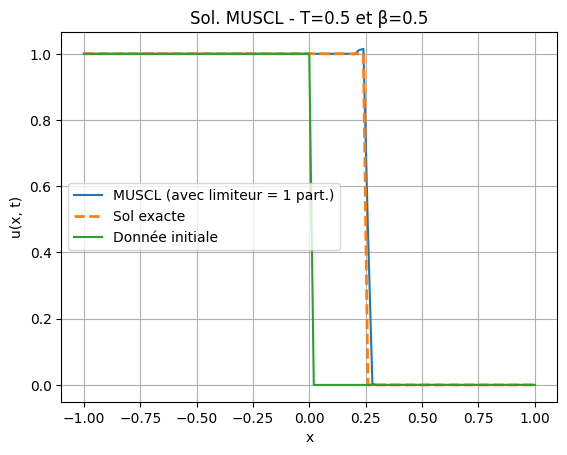

In [ ]:
N = 100
X = np.linspace(-1, 1, N+1)

U0 = u_init(X)
T = 0.5
dt_init = 1e-3
beta = 1./2  #beta = 1 schéma centré


U_muscl1 = solve(X, U0, T, dt_init, beta, no_limiter)
plt.plot(X, U_muscl1, '-', label=f"MUSCL (avec limiteur = 1 part.)")
plt.plot(X, U_ex, '--', linewidth = 2, label=f"Sol exacte")
plt.plot(X, U0, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title(f"Sol. MUSCL - T={T} et β={beta}")
plt.grid()
plt.legend()
plt.savefig("Muscl non limite.png")
plt.show()


In [ ]:
def solve_conv(f, x, u0, T, dt_init, beta, phi):
    dx = x[1]-x[0]
    N = len(x)
    u = np.copy(u0)
    t = 0
    k = 0
    while t<T:
        umax = np.max(np.abs(u) + 1e-10)
        dt = min(dt_init, 0.5*dx/umax)#CFL = 0.9
        if t+dt>T:
            dt = T-t

        #####Etape 1 de RK
        ul, ur = muscl_reconstruction(u, beta, phi)
        u_star = np.zeros_like(u)

        flux = np.array([flux_godunov(ul[i], ur[i]) for i in range(N-1)])
        u_star[1:-1] = u[1:-1] - (0.5*dt/dx)*(flux[1:] - flux[:-1]) + 0.5*dt*f(x[1:-1], t)

        #cdt aux bords (Neumann)
        u_star[0] = u_star[1]
        u_star[-1] = u_star[-2]

        ######Étape 2 de RK
        ul_star, ur_star = muscl_reconstruction(u_star, beta, phi)
        flux_star = np.array([flux_godunov(ul_star[i], ur_star[i]) for i in range(N-1)])

        u[1:-1] = u[1:-1] - (dt/dx)*(flux_star[1:] - flux_star[:-1]) + dt*f(x[1:-1], t)

        #cdt aux bords (Neumann)
        u[0] = u[1]
        u[-1] = u[-2]

        k+=1
        t+= dt


    print(f"Nb. iter = {k}")
    return u

In [ ]:
# je prends u_exact = exp(-(x-t)**2), solution analytique (fabriquée)
def u_exact(x, t):
    return np.exp(-(x-t)**2)
def f(x, t):
    return 2*(x-t)*np.exp(-(x-t)**2)*(1-np.exp(-(x-t)**2))

Nb. iter = 2001
Nb. iter = 2001
Nb. iter = 2001
Ordre de convergence estimé avec dt = 0.00025 : 1.90


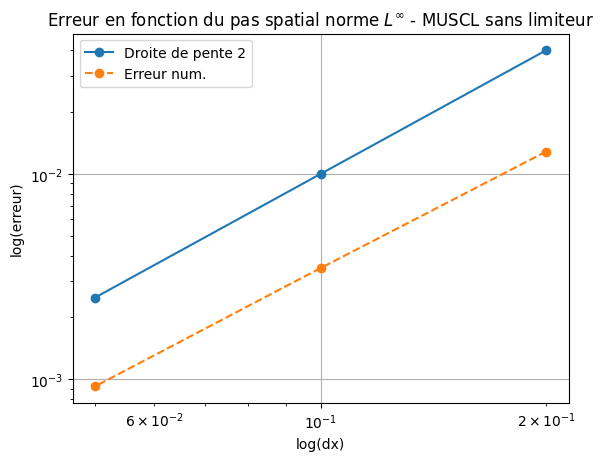

In [ ]:
T = 0.5
dt = 1e-3/4
Nvals = [50, 100, 200]
beta = 1./3
dxvals = []
errors = []

for N in Nvals:
    x = np.linspace(-5, 5, N+1)
    dx = x[1]-x[0]
    dxvals.append(dx)
    u0 = u_exact(x, 0.)
    un = solve_conv(f, x, u0, T, dt, beta, no_limiter)
    u_exN = u_exact(x, T)
    err1 = np.linalg.norm(u_exN - un, np.inf)
    errors.append(err1)



logErrors = np.log(errors)
logdx = np.log(dxvals)

pente2, _ = np.polyfit(logdx, logErrors, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente2:.2f}")



plt.loglog(dxvals, np.array(dxvals)**2, 'o-', label ="Droite de pente 2")
plt.loglog(dxvals, errors, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$ - MUSCL sans limiteur")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.savefig("ordre muscl non limite.png")
plt.show()

In [ ]:
def phi_mc(r):# limiteur monotonized centered
    return np.maximum(0., np.minimum(2*r, np.minimum(0.5*(1 + r), 2.)))

def phi_v(r):
    return (r**2+2*r)/(r**2+ r + 2)

Nb. iter = 2001
Nb. iter = 2001
Nb. iter = 2001
Ordre de convergence estimé avec dt = 0.00025 : 1.51


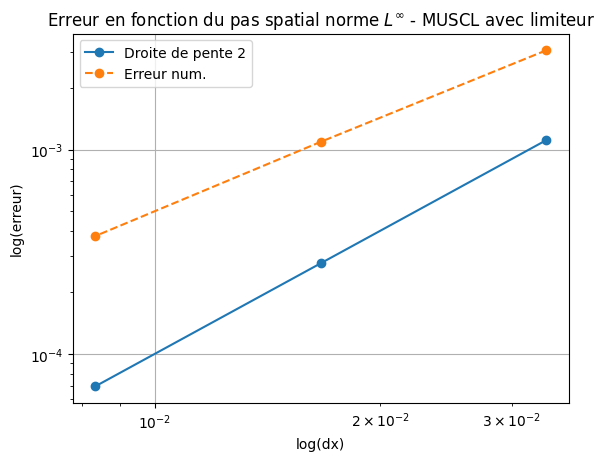

In [ ]:
T = 0.5
dt = 1e-3/4
Nvals = [300, 600, 1200]
beta = 1./3
dxvals = []
errors = []

for N in Nvals:
    x = np.linspace(-5, 5, N+1)
    dx = x[1]-x[0]
    dxvals.append(dx)
    u0 = u_exact(x, 0.)
    un = solve_conv(f, x, u0, T, dt, beta, phi_mc)
    u_exN = u_exact(x, T)
    err1 = np.linalg.norm(u_exN - un, np.inf)
    errors.append(err1)



logErrors = np.log(errors)
logdx = np.log(dxvals)

pente2, _ = np.polyfit(logdx, logErrors, 1)

print(f"Ordre de convergence estimé avec dt = {dt} : {pente2:.2f}")



plt.loglog(dxvals, np.array(dxvals)**2, 'o-', label ="Droite de pente 2")
plt.loglog(dxvals, errors, 'o--', label = "Erreur num.")
plt.title(r"Erreur en fonction du pas spatial norme $L^{\infty}$ - MUSCL avec limiteur")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.legend()
plt.grid()
plt.savefig("ordre muscl limite.png")
plt.show()